In [ ]:
# How does wildfires intensity vary accross regions and where are the highest intensity wildfires detected in the last 5 days?"

In [7]:
import requests
import pandas as pd
import time

#import 
# Range parameter: 5 = last 5 days of detections, before 1
url_api = "https://firms.modaps.eosdis.nasa.gov/api/area/csv/cde635a94746b08c317d8e1c7d3131f7/VIIRS_SNPP_NRT/world/5"
response = requests.get(url_api)

# Check if the request was successful
print(response.status_code) 

fires_df= pd.read_csv(url_api)

fires_df.info()

fires_df.head()

200
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113589 entries, 0 to 113588
Data columns (total 14 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   latitude    113589 non-null  float64
 1   longitude   113589 non-null  float64
 2   bright_ti4  113589 non-null  float64
 3   scan        113589 non-null  float64
 4   track       113589 non-null  float64
 5   acq_date    113589 non-null  object 
 6   acq_time    113589 non-null  int64  
 7   satellite   113589 non-null  object 
 8   instrument  113589 non-null  object 
 9   confidence  113589 non-null  object 
 10  version     113589 non-null  object 
 11  bright_ti5  113589 non-null  float64
 12  frp         113589 non-null  float64
 13  daynight    113589 non-null  object 
dtypes: float64(7), int64(1), object(6)
memory usage: 12.1+ MB


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,-15.40287,167.82909,296.79,0.39,0.36,2026-04-30,1408,N,VIIRS,n,2.0NRT,257.31,0.68,N
1,-15.40228,167.82545,300.31,0.39,0.36,2026-04-30,1408,N,VIIRS,n,2.0NRT,256.76,0.68,N
2,-15.40169,167.82182,301.75,0.39,0.36,2026-04-30,1408,N,VIIRS,n,2.0NRT,254.87,0.69,N
3,-15.40110,167.81818,297.24,0.39,0.36,2026-04-30,1408,N,VIIRS,n,2.0NRT,254.89,0.69,N
4,-15.40012,167.83327,296.95,0.39,0.36,2026-04-30,1408,N,VIIRS,n,2.0NRT,259.33,0.66,N


In [9]:
##inspect and clean the data

# Check for missing values
fires_df.isnull().sum()

# Check confidence levels
fires_df['confidence'].value_counts()

confidence
n    95692
l    13055
h     4842
Name: count, dtype: int64

In [10]:
## convert coordinate into geometry
import geopandas as gpd

fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df['longitude'], fires_df['latitude']),
    crs='EPSG:4326'
)

print(type(fires_gdf))
fires_gdf.head()

<class 'geopandas.geodataframe.GeoDataFrame'>


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry
0,-15.40287,167.82909,296.79,0.39,0.36,2026-04-30,1408,N,VIIRS,n,2.0NRT,257.31,0.68,N,POINT (167.82909 -15.40287)
1,-15.40228,167.82545,300.31,0.39,0.36,2026-04-30,1408,N,VIIRS,n,2.0NRT,256.76,0.68,N,POINT (167.82545 -15.40228)
2,-15.40169,167.82182,301.75,0.39,0.36,2026-04-30,1408,N,VIIRS,n,2.0NRT,254.87,0.69,N,POINT (167.82182 -15.40169)
3,-15.40110,167.81818,297.24,0.39,0.36,2026-04-30,1408,N,VIIRS,n,2.0NRT,254.89,0.69,N,POINT (167.81818 -15.4011)
4,-15.40012,167.83327,296.95,0.39,0.36,2026-04-30,1408,N,VIIRS,n,2.0NRT,259.33,0.66,N,POINT (167.83327 -15.40012)


In [24]:
## Analyze specific properties of the wildfire events

# FRP and brightness
print(" Fire Radiative Power (FRP)")
print(fires_df['frp'].describe().round(2))

print("\nBrightness Temperature (bright_ti4)")
print(fires_df['bright_ti4'].describe().round(2))

#  Day vs night fires
print("\nDay vs Night detections:")
print(fires_df['daynight'].value_counts())

#  Intensity category distribution
print("\nIntensity categories:")
print(fires_df['intensity_cat'].value_counts().sort_index())

# Top 10 most intense fires
print("\nTop 10 most intense fires:")
fires_df.nlargest(10, 'frp')[['latitude', 'longitude', 'frp', 'bright_ti4', 'daynight', 'intensity_cat']]

 Fire Radiative Power (FRP)
count    113589.00
mean          8.18
std          26.10
min           0.00
25%           2.33
50%           4.49
75%           8.23
max        7025.01
Name: frp, dtype: float64

Brightness Temperature (bright_ti4)
count    113589.00
mean        333.33
std          17.45
min         208.00
25%         327.80
50%         336.11
75%         343.81
max         367.00
Name: bright_ti4, dtype: float64

Day vs Night detections:
daynight
D    82582
N    31007
Name: count, dtype: int64

Intensity categories:
intensity_cat
Low         91849
Moderate    19773
High         1838
Extreme       110
Name: count, dtype: int64

Top 10 most intense fires:


,latitude,longitude,frp,bright_ti4,daynight,intensity_cat
113311,29.06994,-95.75277,7025.01,301.16,N,Extreme
84690,53.20477,91.14064,565.36,367.00,D,Extreme
84696,53.20892,91.13199,565.36,367.00,D,Extreme
84697,53.20941,91.14038,565.36,367.00,D,Extreme
105264,33.34603,-112.60073,540.26,367.00,D,Extreme
105272,33.34957,-112.60136,540.26,351.75,D,Extreme
7890,17.92940,-88.82230,462.80,208.00,D,Extreme
7916,17.93563,-88.82287,462.80,367.00,D,Extreme
37260,17.72944,-90.91935,418.84,367.00,D,Extreme
37262,17.73012,-90.91401,418.84,346.48,D,Extreme


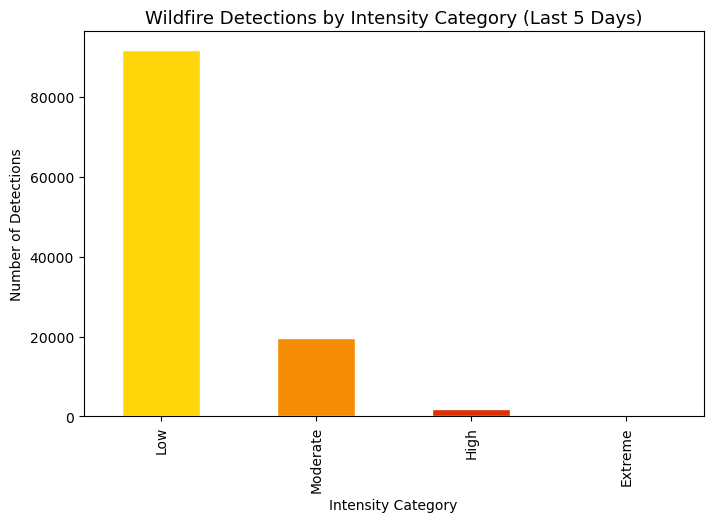

In [29]:
## plot to see distribution 
import matplotlib.pyplot as plt

intensity_counts = fires_df['intensity_cat'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))

intensity_counts.plot(
    kind='bar',
    ax=ax,
    color=['#ffd60a', '#f48c06', '#dc2f02', '#6a040f'],
    edgecolor='white'
)

ax.set_title('Wildfire Detections by Intensity Category (Last 5 Days)', fontsize=13)
ax.set_xlabel('Intensity Category')
ax.set_ylabel('Number of Detections')
plt.show()

